In [1]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
PyTorch: 2.13.0+cpu


In [3]:
data_file = "quantum_encoded_healthcare_data.xlsx"

model_file = (
    "optimized_variational_quantum_model.pt"
)

output_file = (
    "explainability_uncertainty_analysis.xlsx"
)

configuration_file = (
    "explainability_uncertainty_config.json"
)

for required_file in [
    data_file,
    model_file
]:
    if not os.path.exists(required_file):
        raise FileNotFoundError(
            f"{required_file} was not found."
        )

print("Required files found.")

Required files found.


In [4]:
X_test_df = pd.read_excel(
    data_file,
    sheet_name="X_Test_Quantum"
)

y_test_df = pd.read_excel(
    data_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    data_file,
    sheet_name="Class_Mapping"
)

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

y_test = y_test_df[
    "encoded_target"
].to_numpy(dtype=np.int64)

feature_names = X_test_df.columns.tolist()

print("Test features:", X_test.shape)
print("Feature names:", feature_names)
print("Test target:", y_test.shape)

Test features: (100, 4)
Feature names: ['qubit_angle_1', 'qubit_angle_2', 'qubit_angle_3', 'qubit_angle_4']
Test target: (100,)


In [5]:
try:
    checkpoint = torch.load(
        model_file,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        model_file,
        map_location="cpu"
    )

selected_circuit = checkpoint["circuit_name"]
selected_template = checkpoint["template"]
selected_layers = int(checkpoint["layers"])
n_qubits = int(checkpoint["n_qubits"])
n_classes = int(checkpoint["n_classes"])
weight_shapes = checkpoint["weight_shapes"]

print("Circuit:", selected_circuit)
print("Template:", selected_template)
print("Layers:", selected_layers)
print("Qubits:", n_qubits)
print("Classes:", n_classes)

assert X_test.shape[1] == n_qubits

Circuit: Basic_2_Layers
Template: basic
Layers: 2
Qubits: 4
Classes: 12


In [6]:
quantum_device = qml.device(
    "default.qubit",
    wires=n_qubits
)

wires = list(range(n_qubits))

@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def optimized_quantum_circuit(inputs, weights):
    qml.AngleEmbedding(
        features=inputs,
        wires=wires,
        rotation="Y"
    )

    if selected_template == "basic":
        qml.BasicEntanglerLayers(
            weights=weights,
            wires=wires,
            rotation=qml.RY
        )

    elif selected_template == "strong":
        qml.StronglyEntanglingLayers(
            weights=weights,
            wires=wires
        )

    else:
        raise ValueError(
            f"Unknown template: {selected_template}"
        )

    return [
        qml.expval(qml.PauliZ(wire))
        for wire in wires
    ]

In [7]:
class ExplainableQuantumClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            optimized_quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            n_classes
        )

    def forward(self, inputs):
        quantum_features = self.quantum_layer(
            inputs
        )

        return self.output_layer(
            quantum_features
        )


model = ExplainableQuantumClassifier()

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Optimized model loaded.")

Optimized model loaded.


In [8]:
class_mapping.columns = (
    class_mapping.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

encoded_column = (
    "encoded_label"
    if "encoded_label" in class_mapping.columns
    else "encoded_target"
)

medicine_column = (
    "historical_medication_class"
)

if encoded_column not in class_mapping.columns:
    raise KeyError(
        "Encoded class column was not found."
    )

if medicine_column not in class_mapping.columns:
    raise KeyError(
        "Medication class column was not found."
    )

mapping_dictionary = {
    int(encoded_value): str(medicine_class)
    for encoded_value, medicine_class in zip(
        class_mapping[encoded_column],
        class_mapping[medicine_column]
    )
}

print(mapping_dictionary)

{0: 'Acid-suppression class A', 1: 'Acid-suppression class B', 2: 'Antidiabetic class A', 3: 'Antidiabetic class B', 4: 'Antihistamine class A', 5: 'Antihistamine class B', 6: 'Antihypertensive class A', 7: 'Antihypertensive class B', 8: 'Bronchodilator class', 9: 'Controller inhaler class', 10: 'Lipid-lowering class A', 11: 'Lipid-lowering class B'}


In [9]:
def predict_probabilities(
    trained_model,
    features
):
    feature_tensor = torch.tensor(
        features,
        dtype=torch.float32
    )

    trained_model.eval()

    with torch.no_grad():
        logits = trained_model(
            feature_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    return probabilities

In [10]:
baseline_probabilities = predict_probabilities(
    model,
    X_test
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

_, _, baseline_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        baseline_predictions,
        average="macro",
        zero_division=0
    )
)

print("Baseline accuracy:",
      round(baseline_accuracy, 4))

print("Baseline macro F1:",
      round(baseline_macro_f1, 4))

Baseline accuracy: 0.27
Baseline macro F1: 0.198


In [11]:
number_of_permutations = 20
rng = np.random.default_rng(RANDOM_STATE)

permutation_rows = []

for feature_index, feature_name in enumerate(
    feature_names
):
    accuracy_drops = []
    macro_f1_drops = []

    for repetition in range(
        number_of_permutations
    ):
        permuted_features = X_test.copy()

        permuted_features[
            :,
            feature_index
        ] = rng.permutation(
            permuted_features[
                :,
                feature_index
            ]
        )

        probabilities = predict_probabilities(
            model,
            permuted_features
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        permuted_accuracy = accuracy_score(
            y_test,
            predictions
        )

        _, _, permuted_macro_f1, _ = (
            precision_recall_fscore_support(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            )
        )

        accuracy_drops.append(
            baseline_accuracy
            - permuted_accuracy
        )

        macro_f1_drops.append(
            baseline_macro_f1
            - permuted_macro_f1
        )

    permutation_rows.append({
        "feature": feature_name,
        "feature_index": feature_index,
        "mean_accuracy_drop":
            np.mean(accuracy_drops),
        "std_accuracy_drop":
            np.std(accuracy_drops),
        "mean_macro_f1_drop":
            np.mean(macro_f1_drops),
        "std_macro_f1_drop":
            np.std(macro_f1_drops)
    })

permutation_importance = (
    pd.DataFrame(permutation_rows)
    .sort_values(
        "mean_macro_f1_drop",
        ascending=False
    )
    .reset_index(drop=True)
)

display(permutation_importance)

,feature,feature_index,mean_accuracy_drop,std_accuracy_drop,mean_macro_f1_drop,std_macro_f1_drop
0,qubit_angle_1,0,0.0975,0.029133,0.066915,0.026641
1,qubit_angle_2,1,0.0480,0.028213,0.044382,0.022336
2,qubit_angle_3,2,0.0560,0.020347,0.039754,0.018745
3,qubit_angle_4,3,-0.0045,0.027654,0.000085,0.022546


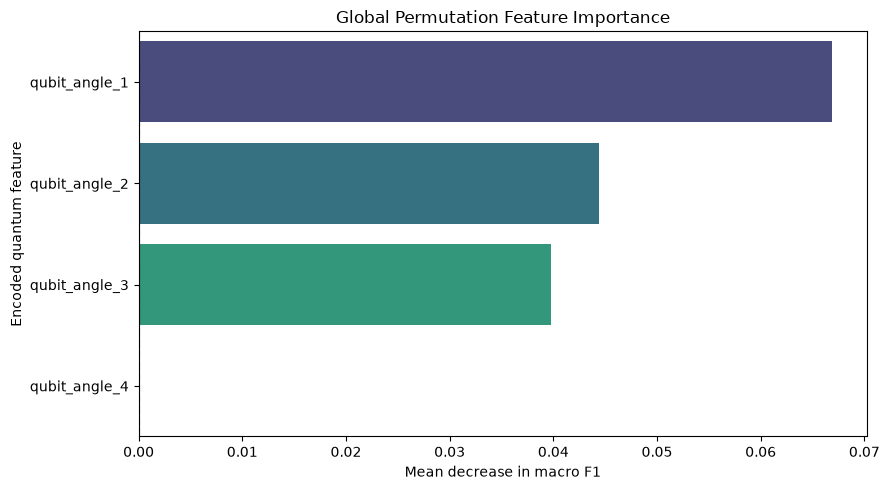

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=permutation_importance,
    x="mean_macro_f1_drop",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Global Permutation Feature Importance"
)
plt.xlabel("Mean decrease in macro F1")
plt.ylabel("Encoded quantum feature")
plt.tight_layout()
plt.show()

In [13]:
local_explanation_rows = []

for record_index in range(len(X_test)):
    input_tensor = torch.tensor(
        X_test[
            record_index:
            record_index + 1
        ],
        dtype=torch.float32,
        requires_grad=True
    )

    model.zero_grad()

    logits = model(input_tensor)

    predicted_class = int(
        torch.argmax(
            logits,
            dim=1
        ).item()
    )

    selected_logit = logits[
        0,
        predicted_class
    ]

    selected_logit.backward()

    gradients = (
        input_tensor.grad
        .detach()
        .cpu()
        .numpy()[0]
    )

    feature_contributions = np.abs(
        gradients
        * X_test[record_index]
    )

    contribution_total = (
        feature_contributions.sum()
    )

    if contribution_total > 0:
        normalized_contributions = (
            feature_contributions
            / contribution_total
        )
    else:
        normalized_contributions = (
            feature_contributions
        )

    explanation_row = {
        "test_record": record_index + 1,
        "actual_encoded_target":
            int(y_test[record_index]),
        "predicted_encoded_target":
            predicted_class,
        "actual_medication_class":
            mapping_dictionary.get(
                int(y_test[record_index]),
                str(y_test[record_index])
            ),
        "predicted_medication_class":
            mapping_dictionary.get(
                predicted_class,
                str(predicted_class)
            )
    }

    for feature_index, feature_name in enumerate(
        feature_names
    ):
        explanation_row[
            f"{feature_name}_value"
        ] = X_test[
            record_index,
            feature_index
        ]

        explanation_row[
            f"{feature_name}_gradient"
        ] = gradients[feature_index]

        explanation_row[
            f"{feature_name}_importance"
        ] = normalized_contributions[
            feature_index
        ]

    most_important_index = int(
        np.argmax(normalized_contributions)
    )

    explanation_row[
        "most_influential_feature"
    ] = feature_names[
        most_important_index
    ]

    local_explanation_rows.append(
        explanation_row
    )

local_explanations = pd.DataFrame(
    local_explanation_rows
)

display(local_explanations.head())

,test_record,actual_encoded_target,predicted_encoded_target,actual_medication_class,predicted_medication_class,qubit_angle_1_value,qubit_angle_1_gradient,qubit_angle_1_importance,qubit_angle_2_value,qubit_angle_2_gradient,qubit_angle_2_importance,qubit_angle_3_value,qubit_angle_3_gradient,qubit_angle_3_importance,qubit_angle_4_value,qubit_angle_4_gradient,qubit_angle_4_importance,most_influential_feature
0,1,9,4,Controller inhaler class,Antihistamine class A,-0.708547,-1.164276,0.317179,-2.628079,0.579256,0.585313,-1.464265,-0.028315,0.015941,-0.595286,-0.356379,0.081567,qubit_angle_2
1,2,2,2,Antidiabetic class A,Antidiabetic class A,1.302774,2.195765,0.407245,0.051602,0.487156,0.003579,-2.193032,0.965724,0.301508,-1.855716,1.088878,0.287668,qubit_angle_1
2,3,10,10,Lipid-lowering class A,Lipid-lowering class A,0.276167,-1.069138,0.361713,-0.844487,-0.545197,0.564033,1.172967,0.046190,0.066373,-0.588884,-0.010923,0.007880,qubit_angle_2
3,4,10,2,Lipid-lowering class A,Antidiabetic class A,0.043428,-0.783568,0.022352,0.502254,0.478998,0.158022,1.224251,0.109344,0.087928,-3.141593,-0.354586,0.731699,qubit_angle_4
4,5,5,4,Antihistamine class B,Antihistamine class A,-1.129610,-0.354589,0.361219,-1.694181,0.140002,0.213900,-1.163933,-0.353647,0.371206,-1.124574,0.052925,0.053675,qubit_angle_3


In [14]:
importance_columns = [
    f"{feature_name}_importance"
    for feature_name in feature_names
]

global_gradient_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_local_importance": [
        local_explanations[
            column
        ].mean()
        for column in importance_columns
    ],
    "std_local_importance": [
        local_explanations[
            column
        ].std()
        for column in importance_columns
    ]
})

global_gradient_importance = (
    global_gradient_importance
    .sort_values(
        "mean_local_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(global_gradient_importance)

,feature,mean_local_importance,std_local_importance
0,qubit_angle_1,0.368888,0.209144
1,qubit_angle_2,0.273568,0.210386
2,qubit_angle_3,0.202743,0.154423
3,qubit_angle_4,0.154801,0.166029


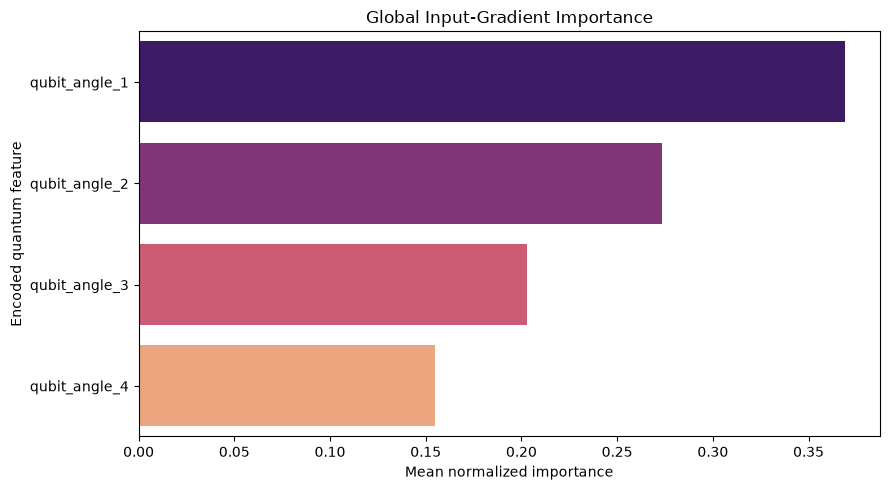

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=global_gradient_importance,
    x="mean_local_importance",
    y="feature",
    hue="feature",
    palette="magma",
    legend=False
)

plt.title(
    "Global Input-Gradient Importance"
)
plt.xlabel("Mean normalized importance")
plt.ylabel("Encoded quantum feature")
plt.tight_layout()
plt.show()

In [16]:
sorted_probabilities = np.sort(
    baseline_probabilities,
    axis=1
)

highest_probability = (
    sorted_probabilities[:, -1]
)

second_highest_probability = (
    sorted_probabilities[:, -2]
)

probability_margin = (
    highest_probability
    - second_highest_probability
)

safe_probabilities = np.clip(
    baseline_probabilities,
    1e-12,
    1.0
)

predictive_entropy = -np.sum(
    safe_probabilities
    * np.log(safe_probabilities),
    axis=1
)

maximum_entropy = np.log(n_classes)

normalized_entropy = (
    predictive_entropy
    / maximum_entropy
)

uncertainty_results = pd.DataFrame({
    "test_record": np.arange(
        1,
        len(X_test) + 1
    ),
    "actual_encoded_target": y_test,
    "predicted_encoded_target":
        baseline_predictions,
    "prediction_correct": (
        y_test == baseline_predictions
    ),
    "prediction_confidence":
        highest_probability,
    "probability_margin":
        probability_margin,
    "predictive_entropy":
        predictive_entropy,
    "normalized_entropy":
        normalized_entropy
})

In [17]:
number_of_uncertainty_runs = 30
perturbation_standard_deviation = 0.05

rng = np.random.default_rng(
    RANDOM_STATE
)

perturbed_probability_runs = []
perturbed_prediction_runs = []

for run in range(
    number_of_uncertainty_runs
):
    noise = rng.normal(
        loc=0.0,
        scale=perturbation_standard_deviation,
        size=X_test.shape
    )

    perturbed_features = np.clip(
        X_test + noise,
        -np.pi,
        np.pi
    ).astype(np.float32)

    run_probabilities = predict_probabilities(
        model,
        perturbed_features
    )

    run_predictions = np.argmax(
        run_probabilities,
        axis=1
    )

    perturbed_probability_runs.append(
        run_probabilities
    )

    perturbed_prediction_runs.append(
        run_predictions
    )

perturbed_probability_runs = np.stack(
    perturbed_probability_runs,
    axis=0
)

perturbed_prediction_runs = np.stack(
    perturbed_prediction_runs,
    axis=0
)

print(
    "Perturbation probability array:",
    perturbed_probability_runs.shape
)

Perturbation probability array: (30, 100, 12)


In [18]:
mean_perturbed_probabilities = (
    perturbed_probability_runs.mean(axis=0)
)

perturbed_safe_probabilities = np.clip(
    perturbed_probability_runs,
    1e-12,
    1.0
)

run_entropies = -np.sum(
    perturbed_safe_probabilities
    * np.log(perturbed_safe_probabilities),
    axis=2
)

mean_run_entropy = run_entropies.mean(
    axis=0
)

mean_probability_safe = np.clip(
    mean_perturbed_probabilities,
    1e-12,
    1.0
)

perturbation_predictive_entropy = -np.sum(
    mean_probability_safe
    * np.log(mean_probability_safe),
    axis=1
)

perturbation_disagreement = (
    perturbation_predictive_entropy
    - mean_run_entropy
)

prediction_stability = np.mean(
    perturbed_prediction_runs
    == baseline_predictions[None, :],
    axis=0
)

variation_ratio = []

for record_index in range(len(X_test)):
    class_votes = np.bincount(
        perturbed_prediction_runs[
            :,
            record_index
        ],
        minlength=n_classes
    )

    maximum_vote_fraction = (
        class_votes.max()
        / number_of_uncertainty_runs
    )

    variation_ratio.append(
        1.0 - maximum_vote_fraction
    )

uncertainty_results[
    "perturbation_prediction_stability"
] = prediction_stability

uncertainty_results[
    "perturbation_variation_ratio"
] = variation_ratio

uncertainty_results[
    "perturbation_disagreement"
] = perturbation_disagreement

In [19]:
high_entropy_threshold = np.quantile(
    normalized_entropy,
    0.75
)

low_margin_threshold = np.quantile(
    probability_margin,
    0.25
)

low_stability_threshold = np.quantile(
    prediction_stability,
    0.25
)

def assign_uncertainty_level(row):
    high_uncertainty_count = 0

    if (
        row["normalized_entropy"]
        >= high_entropy_threshold
    ):
        high_uncertainty_count += 1

    if (
        row["probability_margin"]
        <= low_margin_threshold
    ):
        high_uncertainty_count += 1

    if (
        row[
            "perturbation_prediction_stability"
        ]
        <= low_stability_threshold
    ):
        high_uncertainty_count += 1

    if high_uncertainty_count >= 2:
        return "High uncertainty"

    if high_uncertainty_count == 1:
        return "Moderate uncertainty"

    return "Low uncertainty"


uncertainty_results[
    "uncertainty_level"
] = uncertainty_results.apply(
    assign_uncertainty_level,
    axis=1
)

uncertainty_results[
    "professional_review_flag"
] = (
    uncertainty_results[
        "uncertainty_level"
    ] == "High uncertainty"
)

print(
    uncertainty_results[
        "uncertainty_level"
    ].value_counts()
)

uncertainty_level
Moderate uncertainty    59
High uncertainty        41
Name: count, dtype: int64


In [20]:
uncertainty_results[
    "actual_medication_class"
] = [
    mapping_dictionary.get(
        int(class_id),
        f"Class_{class_id}"
    )
    for class_id in y_test
]

uncertainty_results[
    "predicted_medication_class"
] = [
    mapping_dictionary.get(
        int(class_id),
        f"Class_{class_id}"
    )
    for class_id in baseline_predictions
]

display(uncertainty_results.head(10))

,test_record,actual_encoded_target,predicted_encoded_target,prediction_correct,prediction_confidence,probability_margin,predictive_entropy,normalized_entropy,perturbation_prediction_stability,perturbation_variation_ratio,perturbation_disagreement,uncertainty_level,professional_review_flag,actual_medication_class,predicted_medication_class
0,1,9,4,False,0.216870,0.064173,2.046604,0.823614,1.000000,0.000000,0.000475,Moderate uncertainty,False,Controller inhaler class,Antihistamine class A
1,2,2,2,True,0.531624,0.186295,1.110359,0.446841,1.000000,0.000000,0.001046,Moderate uncertainty,False,Antidiabetic class A,Antidiabetic class A
2,3,10,10,True,0.253485,0.097534,2.227477,0.896403,1.000000,0.000000,0.001412,High uncertainty,True,Lipid-lowering class A,Lipid-lowering class A
3,4,10,2,False,0.155397,0.017997,2.334845,0.939611,1.000000,0.000000,0.001651,High uncertainty,True,Lipid-lowering class A,Antidiabetic class A
4,5,5,4,False,0.246902,0.071979,1.894952,0.762585,1.000000,0.000000,0.000059,Moderate uncertainty,False,Antihistamine class B,Antihistamine class A
5,6,8,10,False,0.217762,0.069618,2.301238,0.926086,1.000000,0.000000,0.001247,High uncertainty,True,Bronchodilator class,Lipid-lowering class A
6,7,7,6,False,0.128985,0.004258,2.449886,0.985906,0.966667,0.033333,0.003208,High uncertainty,True,Antihypertensive class B,Antihypertensive class A
7,8,3,3,True,0.493314,0.031199,0.912911,0.367382,0.900000,0.100000,0.000457,Moderate uncertainty,False,Antidiabetic class B,Antidiabetic class B
8,9,5,10,False,0.221248,0.072030,2.302776,0.926705,1.000000,0.000000,0.000640,High uncertainty,True,Antihistamine class B,Lipid-lowering class A
9,10,6,7,False,0.383696,0.191505,1.912557,0.769670,1.000000,0.000000,0.001434,Moderate uncertainty,False,Antihypertensive class A,Antihypertensive class B


In [21]:
class_uncertainty = (
    uncertainty_results
    .groupby(
        [
            "actual_encoded_target",
            "actual_medication_class"
        ],
        as_index=False
    )
    .agg(
        sample_count=(
            "test_record",
            "count"
        ),
        class_accuracy=(
            "prediction_correct",
            "mean"
        ),
        mean_confidence=(
            "prediction_confidence",
            "mean"
        ),
        mean_probability_margin=(
            "probability_margin",
            "mean"
        ),
        mean_normalized_entropy=(
            "normalized_entropy",
            "mean"
        ),
        mean_perturbation_stability=(
            "perturbation_prediction_stability",
            "mean"
        ),
        high_uncertainty_count=(
            "professional_review_flag",
            "sum"
        )
    )
)

display(class_uncertainty)

,actual_encoded_target,actual_medication_class,sample_count,class_accuracy,mean_confidence,mean_probability_margin,mean_normalized_entropy,mean_perturbation_stability,high_uncertainty_count
0,0,Acid-suppression class A,8,0.000000,0.196338,0.031914,0.828703,0.933333,3
1,1,Acid-suppression class B,7,0.000000,0.185743,0.025122,0.854112,0.861905,3
2,2,Antidiabetic class A,9,0.555556,0.535332,0.147924,0.405834,1.000000,0
3,3,Antidiabetic class B,8,0.375000,0.442515,0.074524,0.518689,0.933333,2
4,4,Antihistamine class A,10,0.900000,0.200020,0.034380,0.839607,1.000000,3
5,5,Antihistamine class B,8,0.000000,0.207832,0.048356,0.852755,0.987500,4
6,6,Antihypertensive class A,9,0.333333,0.397310,0.067052,0.610011,0.977778,1
7,7,Antihypertensive class B,9,0.222222,0.261123,0.061506,0.834881,0.948148,3
8,8,Bronchodilator class,7,0.000000,0.209915,0.055813,0.862009,0.938095,5
9,9,Controller inhaler class,10,0.100000,0.193292,0.032601,0.860161,0.963333,7


In [22]:
explanation_agreement = (
    permutation_importance[
        [
            "feature",
            "mean_macro_f1_drop"
        ]
    ]
    .merge(
        global_gradient_importance[
            [
                "feature",
                "mean_local_importance"
            ]
        ],
        on="feature",
        how="inner"
    )
)

explanation_agreement[
    "permutation_rank"
] = (
    explanation_agreement[
        "mean_macro_f1_drop"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

explanation_agreement[
    "gradient_rank"
] = (
    explanation_agreement[
        "mean_local_importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

explanation_agreement[
    "rank_difference"
] = (
    explanation_agreement[
        "permutation_rank"
    ]
    - explanation_agreement[
        "gradient_rank"
    ]
).abs()

display(explanation_agreement)

,feature,mean_macro_f1_drop,mean_local_importance,permutation_rank,gradient_rank,rank_difference
0,qubit_angle_1,0.066915,0.368888,1.0,1.0,0.0
1,qubit_angle_2,0.044382,0.273568,2.0,2.0,0.0
2,qubit_angle_3,0.039754,0.202743,3.0,3.0,0.0
3,qubit_angle_4,0.000085,0.154801,4.0,4.0,0.0


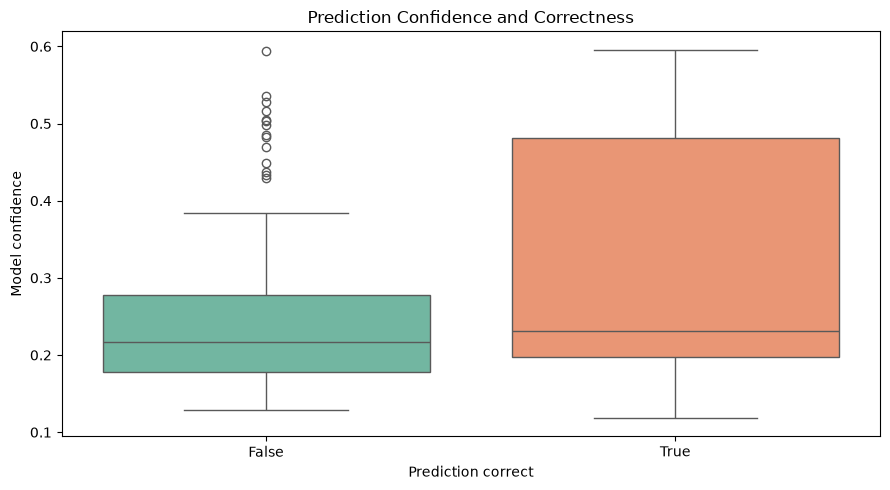

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=uncertainty_results,
    x="prediction_correct",
    y="prediction_confidence",
    hue="prediction_correct",
    palette="Set2",
    legend=False
)

plt.title(
    "Prediction Confidence and Correctness"
)
plt.xlabel("Prediction correct")
plt.ylabel("Model confidence")
plt.tight_layout()
plt.show()

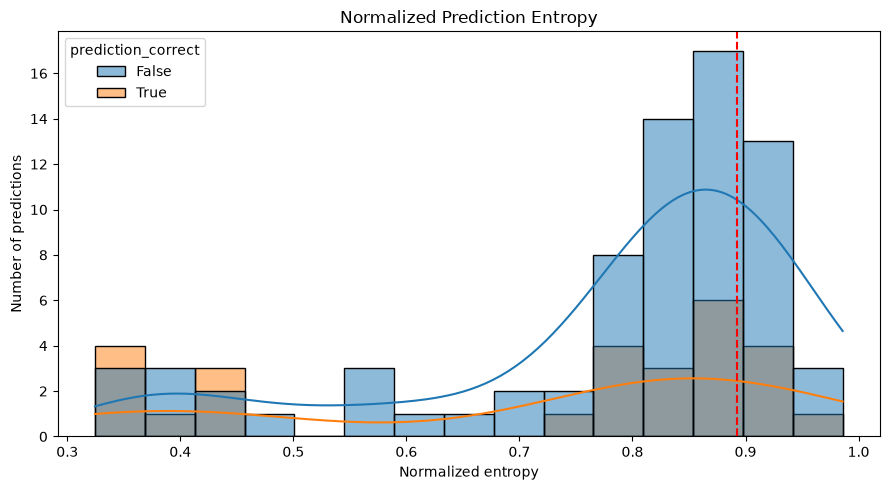

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=uncertainty_results,
    x="normalized_entropy",
    hue="prediction_correct",
    bins=15,
    kde=True,
    multiple="layer"
)

plt.axvline(
    high_entropy_threshold,
    color="red",
    linestyle="--",
    label="High-uncertainty threshold"
)

plt.title("Normalized Prediction Entropy")
plt.xlabel("Normalized entropy")
plt.ylabel("Number of predictions")
plt.tight_layout()
plt.show()

In [25]:
uncertainty_summary = pd.DataFrame({
    "measure": [
        "Total test predictions",
        "Correct predictions",
        "Incorrect predictions",
        "Mean confidence",
        "Mean probability margin",
        "Mean normalized entropy",
        "Mean perturbation stability",
        "Low-uncertainty predictions",
        "Moderate-uncertainty predictions",
        "High-uncertainty predictions",
        "Professional-review flags"
    ],
    "value": [
        len(uncertainty_results),

        uncertainty_results[
            "prediction_correct"
        ].sum(),

        (
            ~uncertainty_results[
                "prediction_correct"
            ]
        ).sum(),

        uncertainty_results[
            "prediction_confidence"
        ].mean(),

        uncertainty_results[
            "probability_margin"
        ].mean(),

        uncertainty_results[
            "normalized_entropy"
        ].mean(),

        uncertainty_results[
            "perturbation_prediction_stability"
        ].mean(),

        (
            uncertainty_results[
                "uncertainty_level"
            ] == "Low uncertainty"
        ).sum(),

        (
            uncertainty_results[
                "uncertainty_level"
            ] == "Moderate uncertainty"
        ).sum(),

        (
            uncertainty_results[
                "uncertainty_level"
            ] == "High uncertainty"
        ).sum(),

        uncertainty_results[
            "professional_review_flag"
        ].sum()
    ]
})

display(uncertainty_summary)

,measure,value
0,Total test predictions,100.000000
1,Correct predictions,27.000000
2,Incorrect predictions,73.000000
3,Mean confidence,0.274564
4,Mean probability margin,0.056852
5,Mean normalized entropy,0.766809
6,Mean perturbation stability,0.956333
7,Low-uncertainty predictions,0.000000
8,Moderate-uncertainty predictions,59.000000
9,High-uncertainty predictions,41.000000


In [26]:
assert baseline_probabilities.shape == (
    len(X_test),
    n_classes
)

assert np.allclose(
    baseline_probabilities.sum(axis=1),
    1.0,
    atol=1e-6
)

assert uncertainty_results[
    "prediction_confidence"
].between(0, 1).all()

assert uncertainty_results[
    "normalized_entropy"
].between(0, 1.000001).all()

assert uncertainty_results[
    "perturbation_prediction_stability"
].between(0, 1).all()

assert uncertainty_results[
    "perturbation_variation_ratio"
].between(0, 1).all()

assert np.allclose(
    local_explanations[
        importance_columns
    ].sum(axis=1),
    1.0,
    atol=1e-5
)

print(
    "All explainability and uncertainty "
    "checks passed."
)

All explainability and uncertainty checks passed.


In [27]:
configuration = {
    "stage": (
        "Explainability and Uncertainty Analysis"
    ),
    "input_model": model_file,
    "circuit": selected_circuit,
    "global_explainability_methods": [
        "Permutation importance",
        "Mean input-gradient importance"
    ],
    "local_explanation_method": (
        "Absolute input multiplied by predicted-logit gradient"
    ),
    "uncertainty_methods": [
        "Prediction confidence",
        "Probability margin",
        "Predictive entropy",
        "Input-perturbation stability",
        "Variation ratio"
    ],
    "permutation_repetitions":
        number_of_permutations,
    "uncertainty_runs":
        number_of_uncertainty_runs,
    "perturbation_standard_deviation":
        perturbation_standard_deviation,
    "high_entropy_threshold":
        float(high_entropy_threshold),
    "low_margin_threshold":
        float(low_margin_threshold),
    "low_stability_threshold":
        float(low_stability_threshold),
    "feature_interpretation_limitation": (
        "Features are PCA-derived quantum components "
        "and do not directly represent original clinical fields"
    )
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    uncertainty_summary.to_excel(
        writer,
        sheet_name="Analysis_Summary",
        index=False
    )

    permutation_importance.to_excel(
        writer,
        sheet_name="Permutation_Importance",
        index=False
    )

    global_gradient_importance.to_excel(
        writer,
        sheet_name="Gradient_Importance",
        index=False
    )

    explanation_agreement.to_excel(
        writer,
        sheet_name="Explanation_Agreement",
        index=False
    )

    local_explanations.to_excel(
        writer,
        sheet_name="Local_Explanations",
        index=False
    )

    uncertainty_results.to_excel(
        writer,
        sheet_name="Prediction_Uncertainty",
        index=False
    )

    class_uncertainty.to_excel(
        writer,
        sheet_name="Class_Uncertainty",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved analysis:", output_file)
print("Saved configuration:", configuration_file)

Saved analysis: explainability_uncertainty_analysis.xlsx
Saved configuration: explainability_uncertainty_config.json


In [28]:
for file_name in [
    output_file,
    configuration_file
]:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

saved_workbook = pd.ExcelFile(output_file)

print("\nSaved sheets:")
print(saved_workbook.sheet_names)

print("\nMean confidence:",
      round(
          uncertainty_results[
              "prediction_confidence"
          ].mean(),
          4
      ))

print(
    "Mean normalized entropy:",
    round(
        uncertainty_results[
            "normalized_entropy"
        ].mean(),
        4
    )
)

print(
    "Mean perturbation stability:",
    round(
        uncertainty_results[
            "perturbation_prediction_stability"
        ].mean(),
        4
    )
)

print(
    "High-uncertainty review flags:",
    uncertainty_results[
        "professional_review_flag"
    ].sum()
)

explainability_uncertainty_analysis.xlsx exists: True
explainability_uncertainty_config.json exists: True

Saved sheets:
['Analysis_Summary', 'Permutation_Importance', 'Gradient_Importance', 'Explanation_Agreement', 'Local_Explanations', 'Prediction_Uncertainty', 'Class_Uncertainty', 'Configuration']

Mean confidence: 0.2746
Mean normalized entropy: 0.7668
Mean perturbation stability: 0.9563
High-uncertainty review flags: 41
